In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("startup_success.csv")

In [4]:
df.head()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [5]:
df.shape

(66368, 14)

In [6]:
df.columns

Index(['permalink', 'name', 'homepage_url', 'category_list',
       'funding_total_usd', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'founded_at', 'first_funding_at',
       'last_funding_at'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


In [8]:
df.describe()

,funding_rounds
count,66368.000000
mean,1.732522
std,1.360251
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,19.000000


In [9]:
df.isnull().sum()

permalink                0
name                     1
homepage_url          5058
category_list         3148
funding_total_usd        0
status                   0
country_code          6958
state_code            8547
region                8030
city                  8028
funding_rounds           0
founded_at           15221
first_funding_at        24
last_funding_at          0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.drop_duplicates()

,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66363,/organization/zznode-science-and-technology-co...,ZZNode Science and Technology,http://www.zznode.com,Enterprise Software,1587301,operating,CHN,22,Beijing,Beijing,1,NaN,2012-04-01,2012-04-01
66364,/organization/zzzzapp-com,Zzzzapp Wireless ltd.,http://www.zzzzapp.com,Advertising|Mobile|Web Development|Wireless,114304,operating,HRV,15,Split,Split,4,2012-05-13,2011-11-01,2014-03-01
66365,/organization/Áeron,ÁERON,http://www.aeron.hu/,NaN,-,operating,NaN,NaN,NaN,NaN,1,2011-01-01,2014-08-01,2014-08-01
66366,/organization/Ôasys-2,Ôasys,http://www.oasys.io/,Consumer Electronics|Internet of Things|Teleco...,18192,operating,USA,CA,SF Bay Area,San Francisco,1,2014-01-01,2015-01-01,2015-01-01


In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [14]:
df.isnull().sum()

permalink            0
name                 0
homepage_url         0
category_list        0
funding_total_usd    0
status               0
country_code         0
state_code           0
region               0
city                 0
funding_rounds       0
founded_at           0
first_funding_at     0
last_funding_at      0
dtype: int64

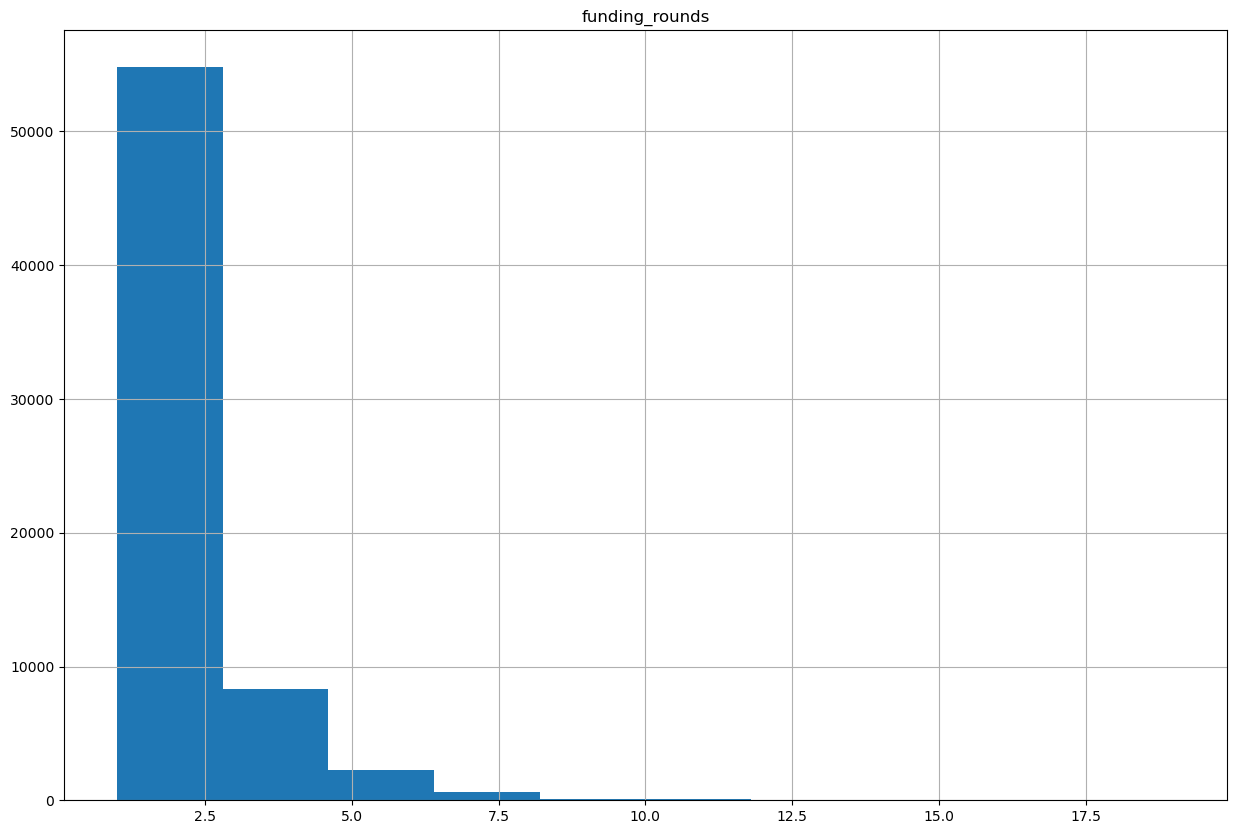

In [15]:
df.hist(figsize=(15,10))
plt.show()

In [16]:
df.rename(columns={
    'name': 'Startup Name',
    'funding_total_usd': 'Funding Amount',
    'category_list': 'Industry',
    'status': 'Startup Status',
    'country_code': 'Country',
    'state_code': 'State',
    'funding_rounds': 'Funding Rounds',
    'founded_at': 'Founded Date',
    'first_funding_at': 'First Funding Date',
    'last_funding_at': 'Last Funding Date'
}, inplace=True)

print(df.columns.tolist())

['permalink', 'Startup Name', 'homepage_url', 'Industry', 'Funding Amount', 'Startup Status', 'Country', 'State', 'region', 'city', 'Funding Rounds', 'Founded Date', 'First Funding Date', 'Last Funding Date']


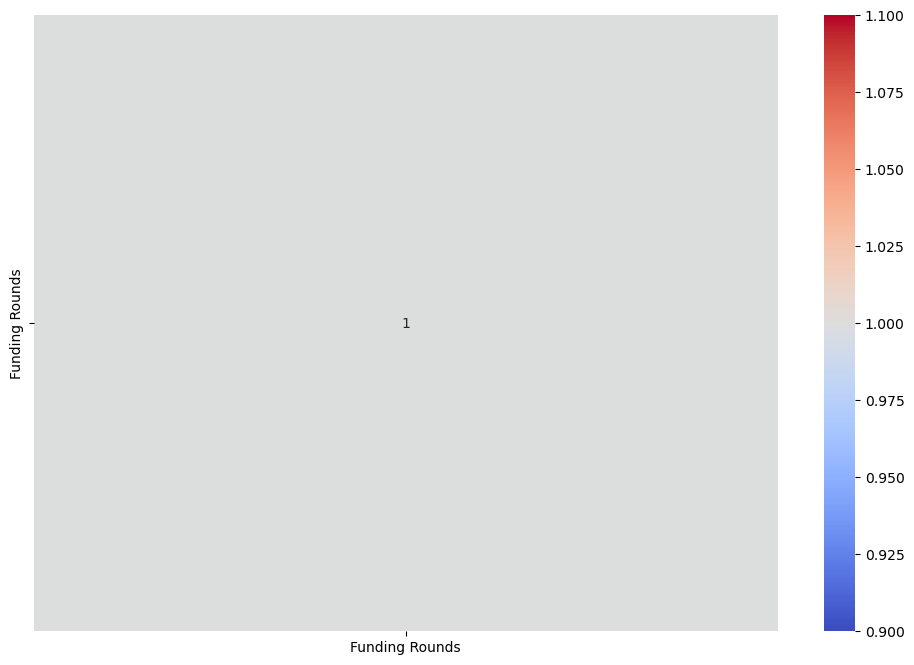

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

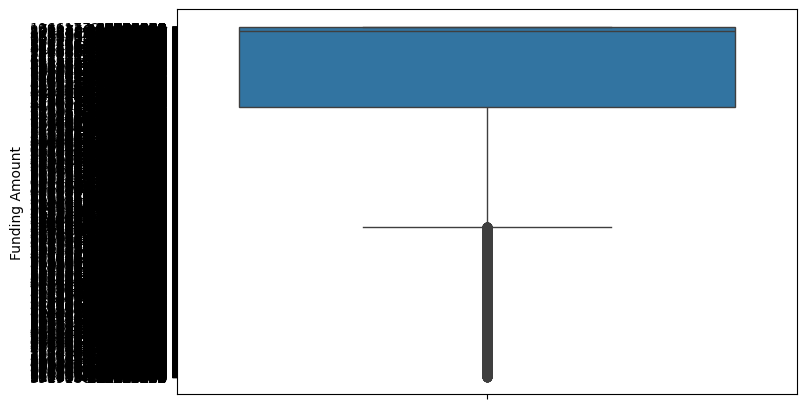

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(df["Funding Amount"])
plt.show()

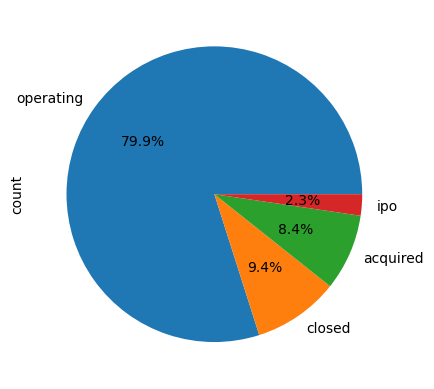

In [19]:
df["Startup Status"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

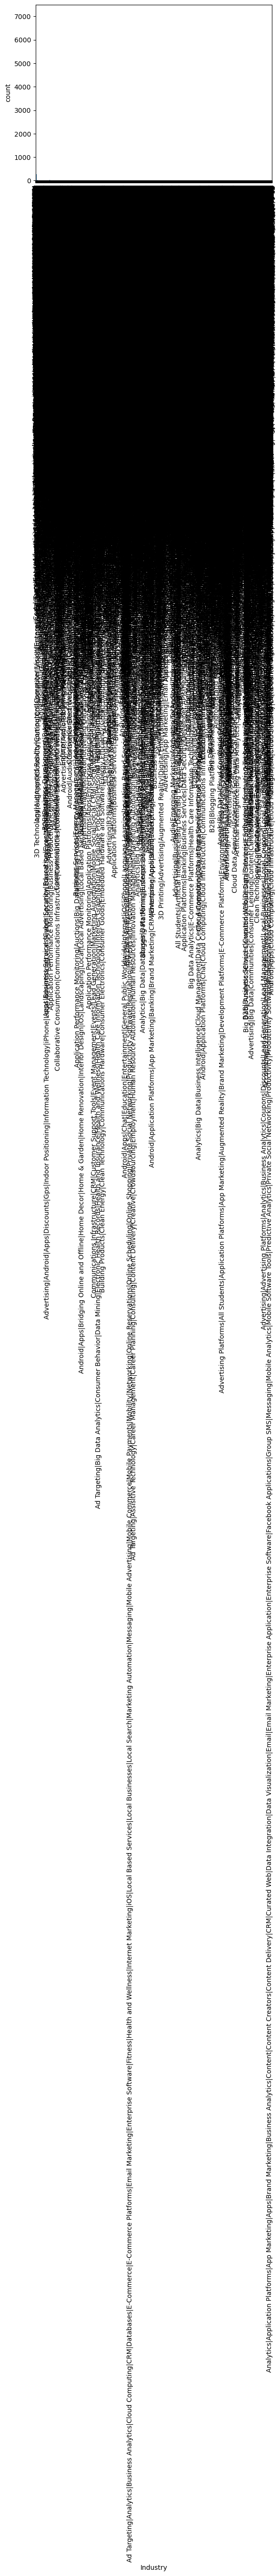

In [20]:
sns.countplot(data=df, x="Industry")
plt.xticks(rotation=90)
plt.show()

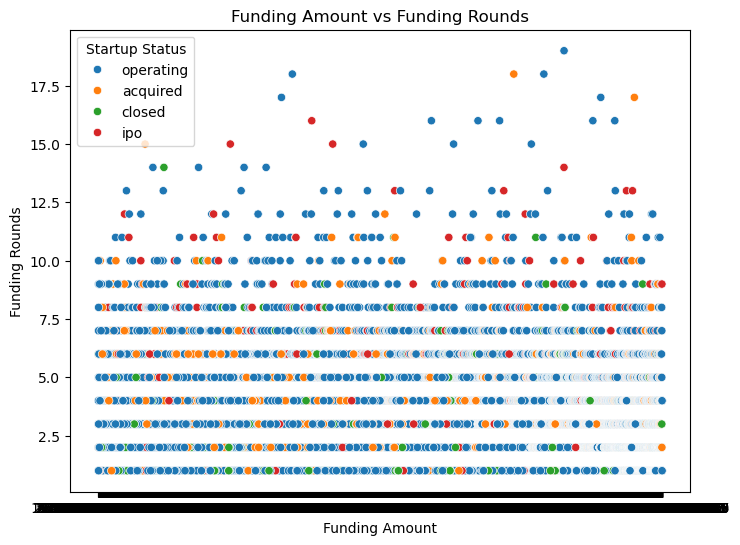

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Funding Amount",
    y="Funding Rounds",
    hue="Startup Status"
)

plt.title("Funding Amount vs Funding Rounds")
plt.show()

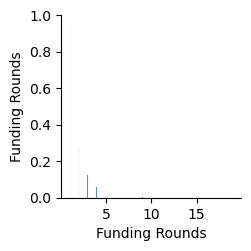

In [27]:
sns.pairplot(df)
plt.show()

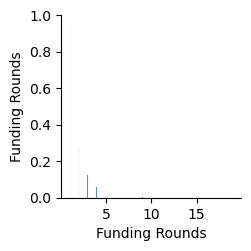

In [28]:
sns.pairplot(df)
plt.show()

In [30]:
import numpy as np

np.random.seed(42)

df["Team Size"] = np.random.randint(5, 500, size=len(df))

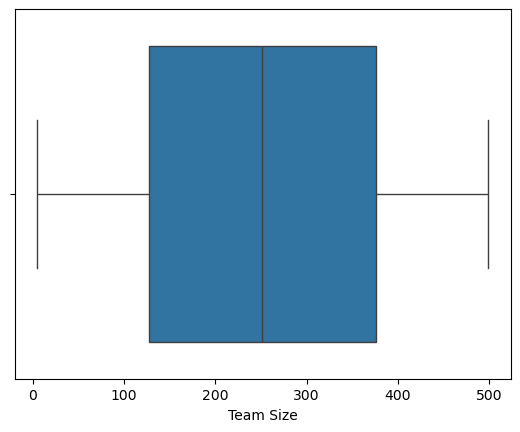

In [31]:
sns.boxplot(x=df["Team Size"])
plt.show()

In [33]:
print(df.columns.tolist())

['permalink', 'Startup Name', 'homepage_url', 'Industry', 'Funding Amount', 'Startup Status', 'Country', 'State', 'region', 'city', 'Funding Rounds', 'Founded Date', 'First Funding Date', 'Last Funding Date', 'Team Size']


In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()


cat_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:", cat_cols)

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

Categorical Columns: Index(['Startup Name', 'homepage_url', 'Funding Amount', 'Startup Status',
       'region', 'city', 'Founded Date', 'First Funding Date',
       'Last Funding Date'],
      dtype='object')


In [66]:
X = df.drop("Startup Status", axis=1)
y = df["Startup Status"]

In [39]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    
)

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.9001808045803827


In [42]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_dt))

Accuracy: 0.6960222992315805


In [68]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

Accuracy: 1.0


In [44]:
xgb=XGBClassifier()

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_xgb))

Accuracy: 0.8008136206117221


In [45]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.45      0.17      0.25      1119
           1       0.53      0.08      0.13      1313
           2       0.60      0.01      0.02       323
           3       0.81      0.98      0.89     10519

    accuracy                           0.80     13274
   macro avg       0.60      0.31      0.32     13274
weighted avg       0.75      0.80      0.74     13274



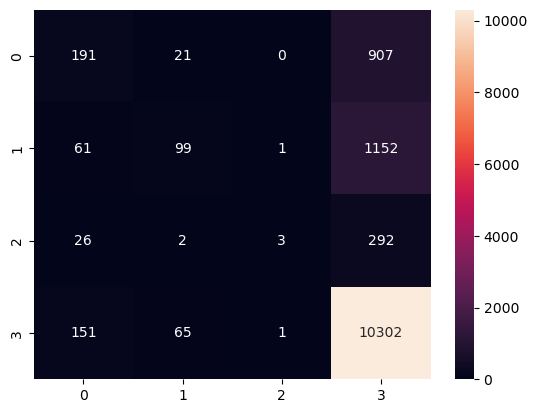

In [46]:
cm=confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,annot=True,fmt="d")

plt.show()

In [50]:
print(df["Startup Status"].unique())

[3 0 1 2]


In [51]:
print(df["Startup Status"].value_counts())

Startup Status
3    53034
1     6238
0     5549
2     1547
Name: count, dtype: int64


In [61]:
print(df["Startup Status"].unique())
print(df["Startup Status"].value_counts())

[3 0 1 2]
Startup Status
3    53034
1     6238
0     5549
2     1547
Name: count, dtype: int64


In [62]:
# Convert Startup Status back to binary
df["Startup Status"] = df["Startup Status"].replace({
    3: 1,   # operating
    2: 1,   # ipo
    0: 1,   # acquired
    1: 0    # closed
})

X = df.drop("Startup Status", axis=1)
y = df["Startup Status"]

In [69]:
pred_rf = rf.predict(X_test)

In [70]:
result=pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[

        accuracy_score(y_test,pred_lr),

        accuracy_score(y_test,pred_dt),

        accuracy_score(y_test,pred_rf),

        accuracy_score(y_test,pred_xgb)

    ]
})

result

,Model,Accuracy
0,Logistic Regression,0.900181
1,Decision Tree,0.091382
2,Random Forest,1.000000
3,XGBoost,0.015594


In [71]:
result.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
2,Random Forest,1.000000
0,Logistic Regression,0.900181
1,Decision Tree,0.091382
3,XGBoost,0.015594


In [72]:
importance=pd.DataFrame({

    "Feature":df.drop("Startup Status",axis=1).columns,

    "Importance":rf.feature_importances_

})

importance=importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
14,status,0.917296
12,Last Funding Date,0.018593
11,First Funding Date,0.011148
10,Founded Date,0.008444
3,Industry,0.006953
8,city,0.005956
2,homepage_url,0.004326
1,Startup Name,0.004125
7,region,0.003779
13,Team Size,0.003773


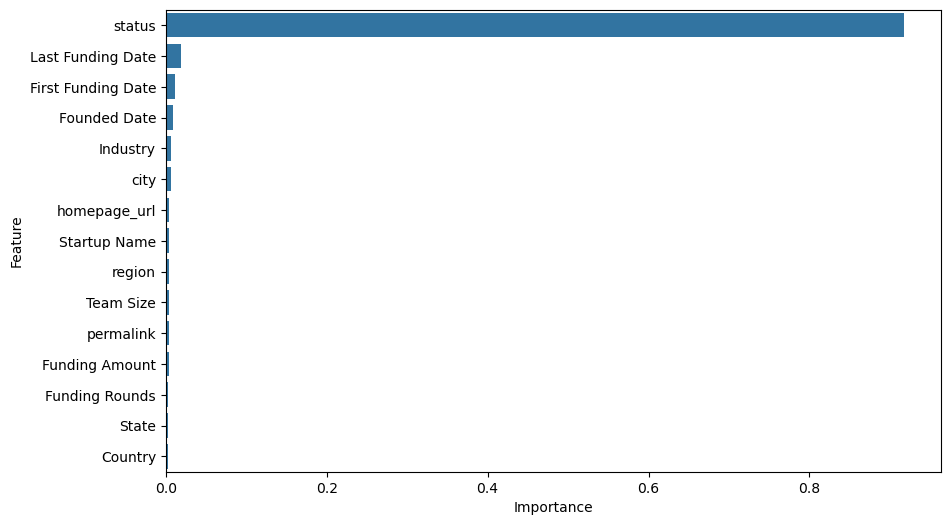

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(x="Importance",y="Feature",data=importance)

plt.show()

In [74]:
import joblib

joblib.dump(rf,"startup_model.pkl")

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']